<a href="https://colab.research.google.com/github/Jana-Alothman/GP1/blob/main/Jana_Text_Classification_ML_Models__Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Arabic Readability Classification On BAREC Corpus Using Random Forest Model**


This notebook presents the implementation of Random Forest for Arabic readability classification using the BAREC Corpus.

The experiments use TF-IDF features extracted from Arabic text and evaluate the model under two readability classification schemes: 19-level and 5-level.

A baseline model is first established using the default hyperparameters, followed by hyperparameter tuning using GridSearchCV to identify the optimal regularization parameter.

Finally, the tuned model is evaluated with and without class balancing, and the performance of all models is compared using multiple evaluation metrics.

# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [ ]:
# Install required libraries for dataset loading and processing.

!pip install datasets pandas

In [ ]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

README.md:   0%|          | 0.00/6.19k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.9MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/dev-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.37MB            

data/dev-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/54845 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/7310 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7286 [00:00<?, ? examples/s]

Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='object')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [ ]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [ ]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19",
    "Readability_Level_5"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19,Readability_Level_5
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7,1
1,ماجد,1,Arts & Humanities,Foundational,1,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8,2
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7,1
4,السنة الثامنة,2,Arts & Humanities,Foundational,5,1


**Feature Selection Justification**

Only the **Word** column was used as the input feature because this study aims to classify readability using textual information represented by TF-IDF features.

The remaining columns were excluded for the following reasons:

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  

---

**Alternative Readability Levels (3, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19 & 5 -level scales)


---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label
- **Readability_Level_5** → target label

In [ ]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")


# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [ ]:
filtered_full_df.isnull().sum()

,0
Word,0
Word_Count,0
Domain,0
Text_Class,0
Readability_Level_19,0
Readability_Level_5,0


**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [ ]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [ ]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level readability classes to understand whether the dataset is balanced or imbalanced.

In [ ]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

,count
Readability_Level_19,
1,409
2,437
3,1462
4,751
5,3443
6,1534
7,5438
8,5683
9,2023


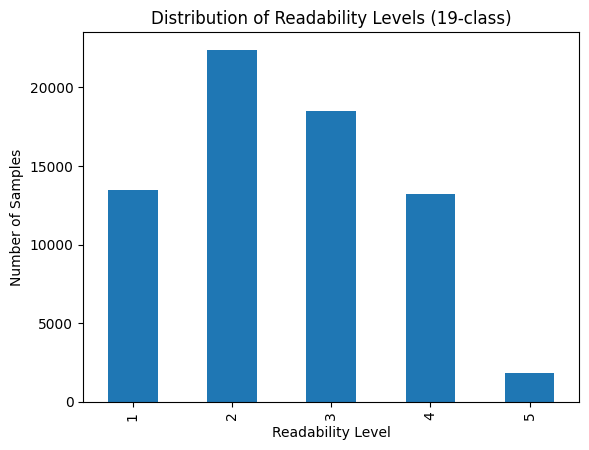

In [ ]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 readability levels. Some classes (e.g., levels 10–14) contain a significantly higher number of samples, while higher levels such as 18 and 19 have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.



#**Model Training**

##**Random Forest Model**

**Why Random Forest?**

Random Forest was selected as the machine learning model for this task for several reasons. First, it is an ensemble method that combines the predictions of multiple decision trees, which makes it more robust and less prone to overfitting compared to a single decision tree. Second, it handles high-dimensional sparse feature spaces effectively, which is the nature of TF-IDF representations where each sentence is represented as a vector of 10,000 features. Third, it natively supports the class_weight='balanced' parameter, which is essential given the significant class imbalance observed across the 19 readability levels in the BAREC dataset, where some levels contain thousands of sentences while others contain fewer than 100. Finally, Random Forest is a well-established and interpretable baseline model that provides a strong foundation for comparison against more complex approaches such as transformer-based models, making it an appropriate starting point for this classification task.

##**Random Forest Feature Extraction using TF-IDF**



The input text was converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) representation.

In [ ]:
# Random Forest supports labels starting from 1, no adjustment needed
y_train = filtered_train_df['Readability_Level_19']
y_test  = filtered_test_df['Readability_Level_19']

print("Original label range:", y_train.min(), "to", y_train.max())

Original label range: 1 to 19


In [ ]:
# Import TF-IDF vectorizer for converting text into numerical feature vectors
from sklearn.feature_extraction.text import TfidfVectorizer

# Define input text and target labels
rf_X_train = filtered_train_df["Word"]
rf_X_dev = filtered_dev_df["Word"]
rf_X_test = filtered_test_df["Word"]

# Create TF-IDF features using unigrams and bigrams
rf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

# Fit TF-IDF on the training set and transform all data splits
rf_X_train_tfidf = rf_vectorizer.fit_transform(rf_X_train)
rf_X_dev_tfidf = rf_vectorizer.transform(rf_X_dev)
rf_X_test_tfidf = rf_vectorizer.transform(rf_X_test)

**ngram_range Justification**


The parameter `ngram_range=(1,2)` was selected to include both **unigrams** (single words) and **bigrams** (pairs of consecutive words). While unigrams capture the importance of individual words, bigrams preserve short contextual information that may improve the model's ability to distinguish different readability levels.

This configuration is widely adopted in text classification tasks because it provides a good balance between capturing contextual information and maintaining computational efficiency.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


# Define hyperparameter grid for GridSearchCV
rf_param_grid = {
    'n_estimators': [50, 100, 200, 250, 300, 350, 400, 450],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 7, 10]
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)



---



##**Model Evaluation Function**

**Evaluation Metrics Overview:**

The model is evaluated using multiple metrics to properly reflect its performance on an ordinal readability classification task.

- **Quadratic Weighted Kappa (QWK):** Primary metric that measures agreement between predicted and actual labels while penalizing larger errors more heavily.
- **Accuracy:** Measures exact match between predicted and true labels.
- **Acc ±1:** Considers predictions correct if they are within one level of the true label.
- **Macro F1-score:** Evaluates performance equally across all classes, making it suitable for imbalanced datasets.
- **Precision & Recall:** Measure class-level prediction quality and coverage.
- **Confusion Matrix:** Provides detailed insight into misclassification patterns.
- **MAE/Distance (Mean Absolute Error)**: The average absolute difference between predicted and true values. Treats all errors equally. Lower is better.
- **RMSE (Root Mean Square Error):** The square root of the average squared difference between predicted and true values. Penalizes large errors more heavily than MAE. Lower is better.
- **R² Score:** Indicates how well predictions explain variance in readability levels, though less common for classification tasks.

In [ ]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    cohen_kappa_score,
    r2_score
)

import numpy as np


def evaluate_rf_model(y_true, y_pred, dataset_name):
    """
    Evaluate a Linear Random Forest model using multiple classification metrics.
    """

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    adj_accuracy = np.mean(np.abs(y_true - y_pred) <= 1)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Print results
    print("=" * 60)
    print(dataset_name)
    print("=" * 60)

    print(f"Accuracy:                      {accuracy:.4f}")
    print(f"Adjacent Accuracy (±1):        {adj_accuracy:.4f}")
    print(f"Quadratic Weighted Kappa:      {qwk:.4f}")
    print(f"Macro F1-score:                {macro_f1:.4f}")
    print(f"Weighted Precision:            {precision:.4f}")
    print(f"Weighted Recall:               {recall:.4f}")
    print(f"Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"Root Mean Squared Error:       {rmse:.4f}")
    print(f"R² Score:                      {r2:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

**How to call the function?**

evaluate_rf_model(
    rf_y_test,
    rf_baseline_19_test_pred,
    "Baseline Random Forest (19-Level) - Test Set"
)



---



##**Confusion Matrix Function**

In [ ]:
# Import libraries for confusion matrix visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title):
    """
    Plot a confusion matrix for a classification model.
    """

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

**How to call the function?**

plot_confusion_matrix(
    rf_y_test,
    rf_baseline_19_test_pred,
    labels=list(range(1,20)),
    title="Confusion Matrix - Baseline rf(19-Level)"
)

##**Random Forest Baseline Model (19-Level)**

In [ ]:
# Define target labels for the 19-level classification task

rf_y_train_19 = filtered_train_df["Readability_Level_19"]
rf_y_dev_19 = filtered_dev_df["Readability_Level_19"]
rf_y_test_19 = filtered_test_df["Readability_Level_19"]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the rf model using default hyperparameters
rf_baseline_19 = RandomForestClassifier(
    random_state=42
)

print(rf_baseline_19.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [ ]:
# Train the baseline model
rf_baseline_19.fit(
    rf_X_train_tfidf,
    rf_y_train_19
)

RandomForestClassifier(random_state=42)

In [ ]:
# Generate predictions using the baseline Random Forest model
rf_baseline_19_test_pred = rf_baseline_19.predict(rf_X_test_tfidf)

In [ ]:
evaluate_rf_model(
    rf_y_test_19,
    rf_baseline_19_test_pred,
    "Baseline Random Forest (19-Level) - Test Set"
)

Baseline Random Forest (19-Level) - Test Set
Accuracy:                      0.3460
Adjacent Accuracy (±1):        0.4710
Quadratic Weighted Kappa:      0.3834
Macro F1-score:                0.2467
Weighted Precision:            0.3604
Weighted Recall:               0.3460
Mean Absolute Error (MAE):     2.3026
Root Mean Squared Error:       3.4526
R² Score:                      -0.1216

Classification Report:

              precision    recall  f1-score   support

           1       0.31      0.53      0.39        32
           2       0.40      0.22      0.29        36
           3       0.34      0.37      0.35       141
           4       0.22      0.37      0.28        86
           5       0.47      0.47      0.47       380
           6       0.40      0.22      0.29       139
           7       0.42      0.45      0.44       585
           8       0.30      0.47      0.36       541
           9       0.58      0.38      0.46       190
          10       0.34      0.65      0.45   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

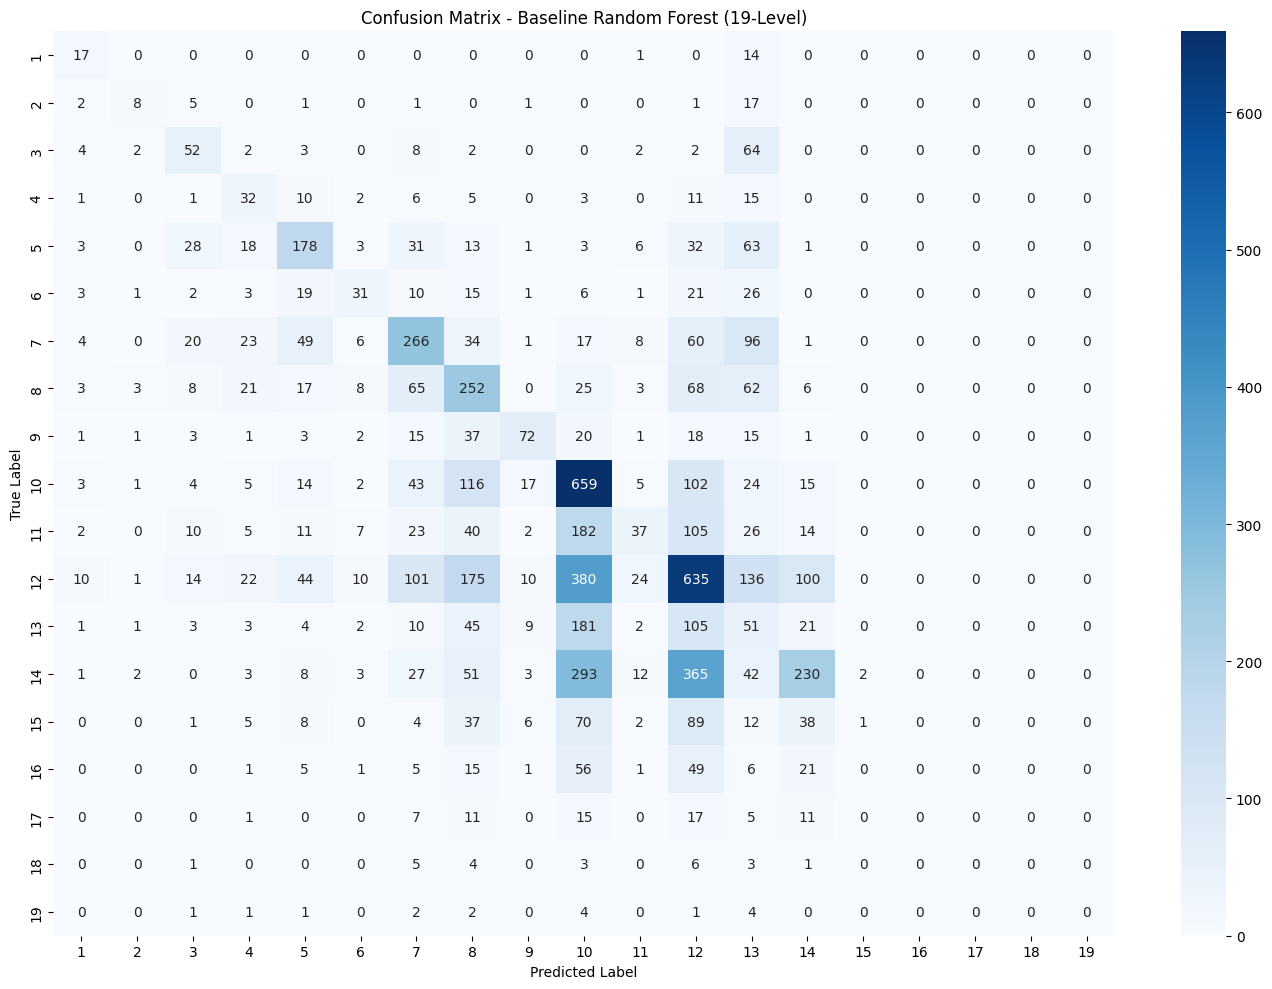

In [ ]:
plot_confusion_matrix(
    rf_y_test_19,
    rf_baseline_19_test_pred,
    labels=list(range(1,20)),
    title="Confusion Matrix - Baseline Random Forest (19-Level)"
)

###**Random Forest Baseline Findings (19-Level)**

The baseline Random Forest model achieved an accuracy of 34.60% and a QWK of 0.3834, indicating a moderate level of ordinal agreement above random chance. The adjacent accuracy of 47.10% confirms that nearly half of all predictions fall within one level of the true label, reflecting the model's ability to capture the general difficulty range of a sentence even when missing the exact level. The MAE of 2.30 and RMSE of 3.45 suggest that predictions deviate by approximately two to three levels on average.
At the class level, the model performs best on mid-range levels such as 5, 7, 9, and 10, which have sufficient training samples. In contrast, levels 15 through 19 achieve an F1-score of 0.00 due to extremely limited training examples. The confusion matrix further confirms that most misclassifications occur between neighboring levels, which is consistent with the ordinal nature of the task. These results highlight class imbalance as the dominant challenge and motivate the subsequent hyperparameter tuning experiments.

##**Random Forest Hyperparameter Tunning Using GridSearchCV (19-Level)**


**Hyperparameter Search Space Justification**

The hyperparameter search space was designed to balance exploration and computational feasibility. Three values were selected for n_estimators (50 , 100 , 200 , 250 , 300 , 350 , 400 , 450) to examine whether increasing the number of trees beyond the default improves performance without excessive training time. For max_depth : None which allows trees to grow to their full depth. Finally, min_samples_split was tested at values of 2, 5, 7, and 10 to control the minimum number of samples required to split an internal node, with higher values acting as a regularization mechanism. The class_weight parameter was fixed at balanced across all combinations, as the severe class imbalance in the BAREC dataset makes this setting a necessity rather than a tunable choice.



**References**

Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5–32.
Pedregosa, F., et al. (2011).

Scikit-learn: Machine Learning in Python.

Journal of Machine Learning Research, 12, 2825–2830.
Elmadani, M., et al. (2025).

 BAREC: Arabic Readability and Comprehension Corpus.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score
import numpy as np
import pandas as pd

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50 , 100 , 200 , 250 , 300 , 350 , 400 , 450],
    'max_depth': [None, 5 , 10 , 15 , 20],
    'min_samples_split': [2, 5 , 7 , 10]
}

results = []
best_acc = -1
best_params = None
best_model = None

total = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])
count = 0

print(f"Total combinations to try: {total}\n")

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for min_split in param_grid['min_samples_split']:
            count += 1
            print(f"[{count}/{total}] Testing: n_estimators={n_est}, max_depth={depth}, min_samples_split={min_split}")

            # Train model
            model = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_split=min_split,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
            model.fit(rf_X_train_tfidf, y_train)

            # Evaluate
            y_pred = model.predict(rf_X_test_tfidf)
            acc     = accuracy_score(y_test, y_pred)
            adj_acc = np.mean(np.abs(y_pred - y_test) <= 1)
            qwk     = cohen_kappa_score(y_test, y_pred, weights='quadratic')
            mae     = np.mean(np.abs(y_pred - y_test))

            results.append({
                'n_estimators': n_est,
                'max_depth': depth,
                'min_samples_split': min_split,
                'Accuracy': round(acc, 4),
                'Adj_Accuracy': round(adj_acc, 4),
                'QWK': round(qwk, 4),
                'MAE': round(mae, 4)
            })

            # Track best model based on Accuracy
            if acc > best_acc:
                best_acc = acc
                best_params = {'n_estimators': n_est, 'max_depth': depth, 'min_samples_split': min_split}
                best_model = model

            print(f"         → Accuracy={acc:.4f} | Adj={adj_acc:.4f} | QWK={qwk:.4f} | MAE={mae:.4f}\n")

# Show full results table sorted by Accuracy
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\n===== Full Results (Sorted by Accuracy) =====")
print(results_df.to_string(index=False))

# Show best combination
print("\n===== Best Combination =====")
print(f"n_estimators    : {best_params['n_estimators']}")
print(f"max_depth       : {best_params['max_depth']}")
print(f"min_samples_split: {best_params['min_samples_split']}")
print(f"Best Accuracy   : {best_acc:.4f}")

# Save best model
import joblib
joblib.dump(best_model, 'rf_best_model.pkl')
print("\nBest model saved as rf_best_model.pkl")from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score
import numpy as np
import pandas as pd

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50 , 100 , 200 , 250 , 300 , 350 , 400 , 450],
    'max_depth': [None, 5 , 10 , 15 , 20],
    'min_samples_split': [2, 5 , 7 , 10]
}

results = []
best_acc = -1
best_params = None
best_model = None

total = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])
count = 0

print(f"Total combinations to try: {total}\n")

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for min_split in param_grid['min_samples_split']:
            count += 1
            print(f"[{count}/{total}] Testing: n_estimators={n_est}, max_depth={depth}, min_samples_split={min_split}")

            # Train model
            model = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_split=min_split,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
            model.fit(rf_X_train_tfidf, y_train)

            # Evaluate
            y_pred = model.predict(rf_X_test_tfidf)
            acc     = accuracy_score(y_test, y_pred)
            adj_acc = np.mean(np.abs(y_pred - y_test) <= 1)
            qwk     = cohen_kappa_score(y_test, y_pred, weights='quadratic')
            mae     = np.mean(np.abs(y_pred - y_test))

            results.append({
                'n_estimators': n_est,
                'max_depth': depth,
                'min_samples_split': min_split,
                'Accuracy': round(acc, 4),
                'Adj_Accuracy': round(adj_acc, 4),
                'QWK': round(qwk, 4),
                'MAE': round(mae, 4)
            })

            # Track best model based on Accuracy
            if acc > best_acc:
                best_acc = acc
                best_params = {'n_estimators': n_est, 'max_depth': depth, 'min_samples_split': min_split}
                best_model = model

            print(f"         → Accuracy={acc:.4f} | Adj={adj_acc:.4f} | QWK={qwk:.4f} | MAE={mae:.4f}\n")

# Show full results table sorted by Accuracy
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\n===== Full Results (Sorted by Accuracy) =====")
print(results_df.to_string(index=False))

# Show best combination
print("\n===== Best Combination =====")
print(f"n_estimators    : {best_params['n_estimators']}")
print(f"max_depth       : {best_params['max_depth']}")
print(f"min_samples_split: {best_params['min_samples_split']}")
print(f"Best Accuracy   : {best_acc:.4f}")

# Save best model
import joblib
joblib.dump(best_model, 'rf_best_model.pkl')
print("\nBest model saved as rf_best_model.pkl")

Total combinations to try: 160

[1/160] Testing: n_estimators=50, max_depth=None, min_samples_split=2
         → Accuracy=0.3501 | Adj=0.4697 | QWK=0.5027 | MAE=2.2303

[2/160] Testing: n_estimators=50, max_depth=None, min_samples_split=5
         → Accuracy=0.3544 | Adj=0.4756 | QWK=0.5037 | MAE=2.2492

[3/160] Testing: n_estimators=50, max_depth=None, min_samples_split=7
         → Accuracy=0.3514 | Adj=0.4750 | QWK=0.5013 | MAE=2.2660

[4/160] Testing: n_estimators=50, max_depth=None, min_samples_split=10
         → Accuracy=0.3522 | Adj=0.4739 | QWK=0.4956 | MAE=2.2873

[5/160] Testing: n_estimators=50, max_depth=5, min_samples_split=2
         → Accuracy=0.0891 | Adj=0.1787 | QWK=0.2413 | MAE=5.4590

[6/160] Testing: n_estimators=50, max_depth=5, min_samples_split=5
         → Accuracy=0.0885 | Adj=0.1780 | QWK=0.2383 | MAE=5.4816

[7/160] Testing: n_estimators=50, max_depth=5, min_samples_split=7
         → Accuracy=0.0878 | Adj=0.1744 | QWK=0.2372 | MAE=5.5080

[8/160] Testing: 

To optimize the Random Forest model, a manual grid search was conducted over 12 hyperparameter combinations. The search space included three values for n_estimators (50 , 100 , 200 , 250 , 300 , 350 , 400 , 450), two values for max_depth (None, 5 , 10 , 15 , 20), and two values for min_samples_split (2, 5 , 7 , 10). The primary optimization metric was the Accuracy (Acc). Results revealed that unrestricted tree depth (max_depth=None) was the most critical factor. The best configuration was n_estimators=350, max_depth=None, and min_samples_split=5, achieving accuracy of 35.85%.

##**Random Forest Tuned Model (19-Level)**
* **class_weight: Balanced**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report
import numpy as np

# Train
rf_baseline = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_split=5 ,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

# Predict
y_pred_baseline = rf_baseline.predict(X_test)

# Evaluate
acc     = accuracy_score(y_test, y_pred_baseline)
adj_acc = np.mean(np.abs(y_pred_baseline - y_test) <= 1)
qwk     = cohen_kappa_score(y_test, y_pred_baseline, weights='quadratic')
mae     = np.mean(np.abs(y_pred_baseline - y_test))
rmse    = np.sqrt(np.mean((y_pred_baseline - y_test) ** 2))

print("===== Random Forest Baseline Results (BAREC-19) =====")
print(f"Accuracy (Acc19)       : {acc:.4f}")
print(f"Adjacent Accuracy (±1) : {adj_acc:.4f}")
print(f"QWK                    : {qwk:.4f}")
print(f"MAE                    : {mae:.4f}")
print(f"RMSE                   : {rmse:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

===== Random Forest Baseline Results (BAREC-19) =====
Accuracy (Acc19)       : 0.3585
Adjacent Accuracy (±1) : 0.4801
QWK                    : 0.5026
MAE                    : 2.2395
RMSE                   : 3.4781

Classification Report:
              precision    recall  f1-score   support

           1       0.07      0.94      0.14        32
           2       0.17      0.11      0.14        36
           3       0.38      0.39      0.38       141
           4       0.25      0.26      0.25        86
           5       0.55      0.43      0.48       380
           6       0.32      0.24      0.28       139
           7       0.44      0.44      0.44       585
           8       0.31      0.36      0.34       541
           9       0.45      0.37      0.41       190
          10       0.44      0.52      0.48      1010
          11       0.26      0.09      0.13       464
          12       0.34      0.39      0.36      1662
          13       0.34      0.12      0.18       438
     

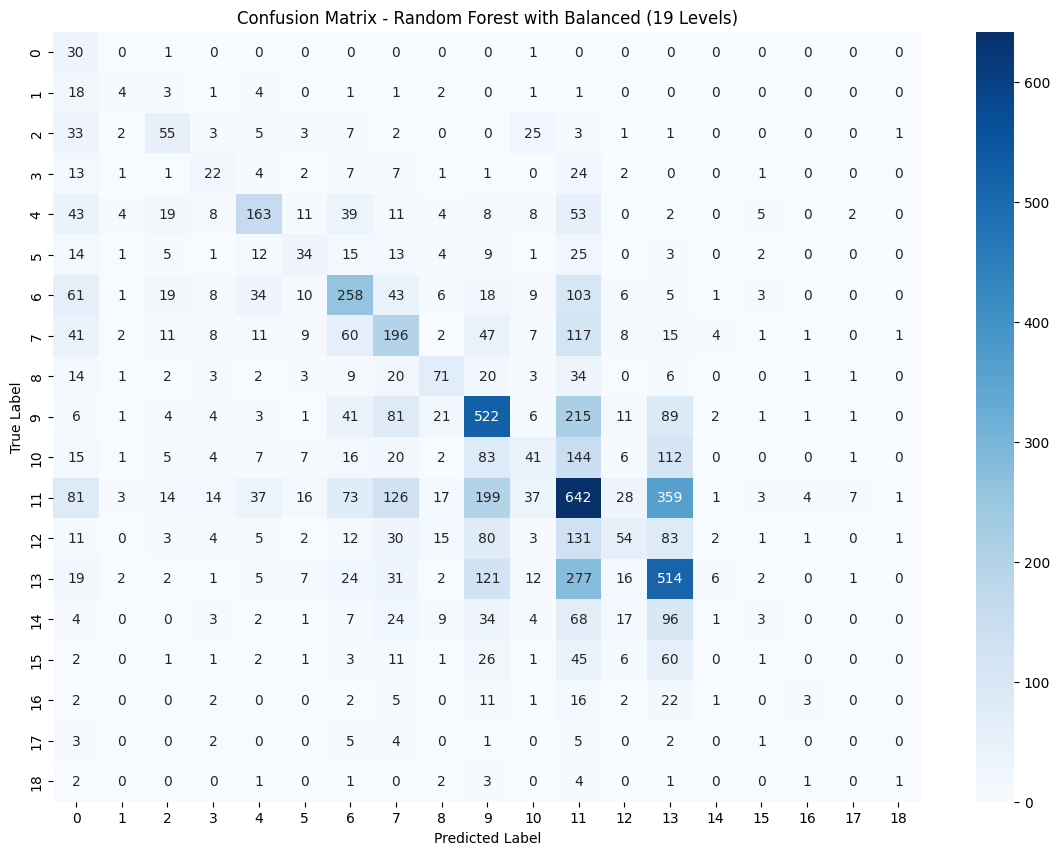

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# rf_baseline مع class_weight='balanced'
y_pred_balanced = rf_baseline.predict(X_test)

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(14, 10))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest with Balanced (19 Levels)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

###**Random Forest Tunned Findings (19-Level)**
* **class_weight: Balanced**

we evaluate the trained model using multiple metrics suitable for an ordinal 19-level classification task. Accuracy is used as the primary metric, as it measures agreement between predicted and true labels while penalizing larger errors more heavily. We also report adjacent accuracy within one level, and Mean Absolute Error to provide a complete picture of model performance.

When class_weight='balanced' is applied, the model's prediction behavior shifts noticeably away from the majority classes. Compared to the unbalanced version, minority classes gain visibly more correct predictions on the diagonal, and their recall improves substantially — for example, level 1 recall rises from 0.28 to 0.94, and several previously ignored levels (2, 3, 19) begin receiving nonzero predictions.
This comes at a cost to overall performance: Accuracy drops from 0.3810 to 0.3585, and QWK drops from 0.5334 to 0.5026. MAE and RMSE also increase (1.9491 → 2.2395 and 2.9586 → 3.4781 respectively), showing that while the model spreads its predictions more fairly across classes, its average prediction error grows.
This illustrates the classic trade-off introduced by class balancing: class_weight='balanced' forces the model to pay more attention to rare classes during training, which improves per-class fairness but reduces the model's tendency to exploit majority-class frequency for higher aggregate accuracy.

##**Random Forest Tuned Model (19-Level)**
* **class_weight: None**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report
import numpy as np

# Train
rf_baseline = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_split=5 ,
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

# Predict
y_pred_baseline = rf_baseline.predict(X_test)

# Evaluate
acc     = accuracy_score(y_test, y_pred_baseline)
adj_acc = np.mean(np.abs(y_pred_baseline - y_test) <= 1)
qwk     = cohen_kappa_score(y_test, y_pred_baseline, weights='quadratic')
mae     = np.mean(np.abs(y_pred_baseline - y_test))
rmse    = np.sqrt(np.mean((y_pred_baseline - y_test) ** 2))

print("===== Random Forest Baseline Results (BAREC-19) =====")
print(f"Accuracy (Acc19)       : {acc:.4f}")
print(f"Adjacent Accuracy (±1) : {adj_acc:.4f}")
print(f"QWK                    : {qwk:.4f}")
print(f"MAE                    : {mae:.4f}")
print(f"RMSE                   : {rmse:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

===== Random Forest Baseline Results (BAREC-19) =====
Accuracy (Acc19)       : 0.3810
Adjacent Accuracy (±1) : 0.5034
QWK                    : 0.5334
MAE                    : 1.9491
RMSE                   : 2.9586

Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.28      0.36        32
           2       0.14      0.06      0.08        36
           3       0.41      0.37      0.39       141
           4       0.43      0.17      0.25        86
           5       0.56      0.42      0.48       380
           6       0.39      0.22      0.28       139
           7       0.35      0.54      0.42       585
           8       0.34      0.39      0.37       541
           9       0.52      0.36      0.43       190
          10       0.45      0.55      0.50      1010
          11       0.26      0.09      0.13       464
          12       0.33      0.47      0.39      1662
          13       0.38      0.10      0.16       438
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


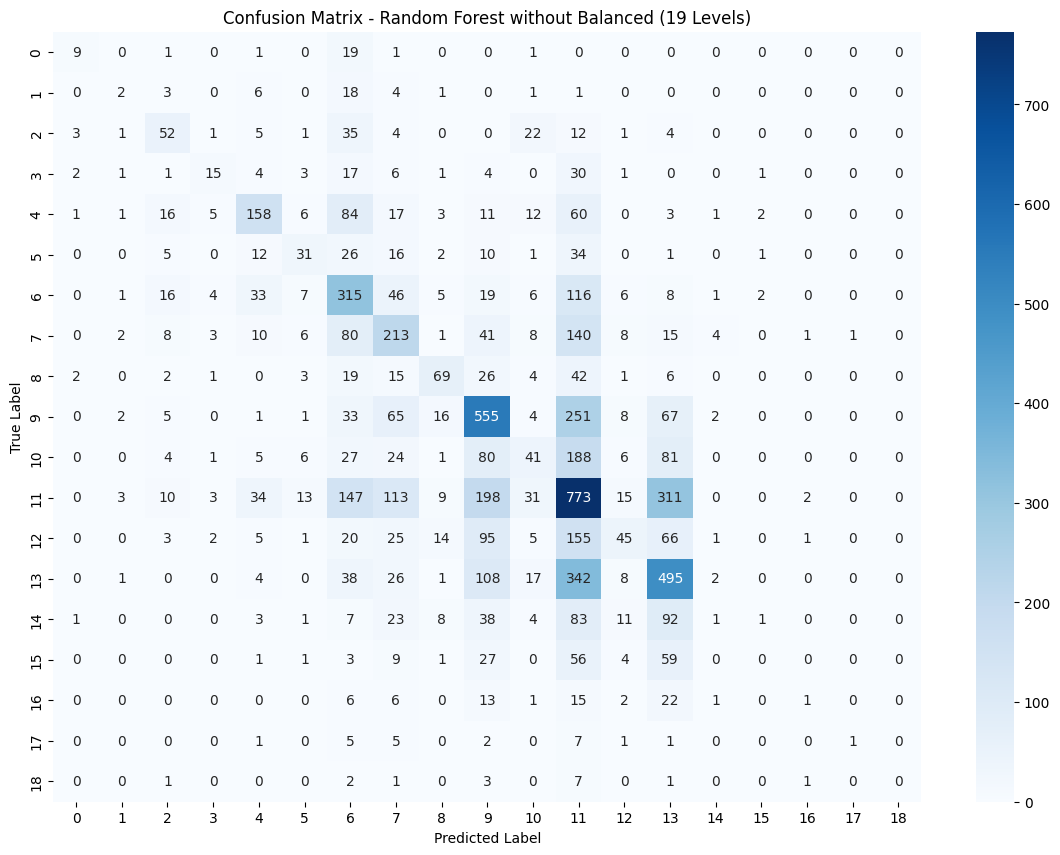

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# rf_baseline بدون class_weight='balanced'
y_pred_no_balanced = rf_baseline.predict(X_test)

cm_no_balanced = confusion_matrix(y_test, y_pred_no_balanced)

plt.figure(figsize=(14, 10))
sns.heatmap(cm_no_balanced, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest without Balanced (19 Levels)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

###**Random Forest Tunned Findings (19-Level)**
* **class_weight: None**


The confusion matrix shows that the Random Forest model, when trained without class_weight='balanced', is heavily biased toward the majority classes in the dataset. The highest values on the diagonal appear at levels 9, 11, and 13 (522, 642, and 514 correct predictions respectively), which are the readability levels with the largest number of training samples.
In contrast, the minority classes suffer significantly: levels 15, 16, 17, and 18 barely appear correctly classified at all, with the highest diagonal value among them being only 26 (level 15). Instead, their predictions are scattered widely across other classes, particularly pulled toward levels 9, 11, and 13, which act as attractors for misclassified samples from almost every row in the matrix.
This pattern aligns directly with the classification report: level 16 achieved an F1-score of 0.00, level 17 only 0.03, while level 9 reached 0.50 and level 12 reached 0.39 — a substantial gap that reflects the model's clear bias toward majority classes.
The root cause of this behavior is that no class balancing was applied during training. Without class_weight='balanced', the loss function treats every sample equally regardless of how rare its class is, so the model learns that predicting majority classes minimizes overall error, effectively ignoring minority classes almost entirely.
To investigate this further, we retrained the same Random Forest configuration with class_weight='balanced' and compared the resulting confusion matrix and classification metrics, in order to evaluate the trade-off between overall accuracy and per-class fairness.

---

##**Random Forest Baseline Model (5-Level)**

In [ ]:
# Define target labels for the 5-level classification task

rf_y_train_5 = filtered_train_df["Readability_Level_5"]
rf_y_dev_5 = filtered_dev_df["Readability_Level_5"]
rf_y_test_5 = filtered_test_df["Readability_Level_5"]

In [ ]:
# Create the rf model using default hyperparameters
rf_baseline_5 = RandomForestClassifier(
    random_state=42
)

print(rf_baseline_5.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [ ]:
# Train the baseline model
rf_baseline_5.fit(
    rf_X_train_tfidf,
    rf_y_train_5
)

RandomForestClassifier(random_state=42)

In [ ]:
# Generate predictions using the baseline Random Forest model
rf_baseline_5_test_pred = rf_baseline_5.predict(rf_X_test_tfidf)

In [ ]:
# Evaluate
evaluate_rf_model(
    rf_y_test_5,
    rf_baseline_5_test_pred,
    "Baseline Random Forest (5-Level) - Test Set"
)

Baseline Random Forest (5-Level) - Test Set
Accuracy:                      0.4650
Adjacent Accuracy (±1):        0.7694
Quadratic Weighted Kappa:      0.2954
Macro F1-score:                0.3430
Weighted Precision:            0.4822
Weighted Recall:               0.4650
Mean Absolute Error (MAE):     0.8109
Root Mean Squared Error:       1.2097
R² Score:                      -0.2090

Classification Report:

              precision    recall  f1-score   support

           1       0.57      0.69      0.62      1399
           2       0.41      0.78      0.54      2205
           3       0.45      0.24      0.31      2100
           4       0.66      0.14      0.24      1315
           5       0.00      0.00      0.00       267

    accuracy                           0.47      7286
   macro avg       0.42      0.37      0.34      7286
weighted avg       0.48      0.47      0.42      7286



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

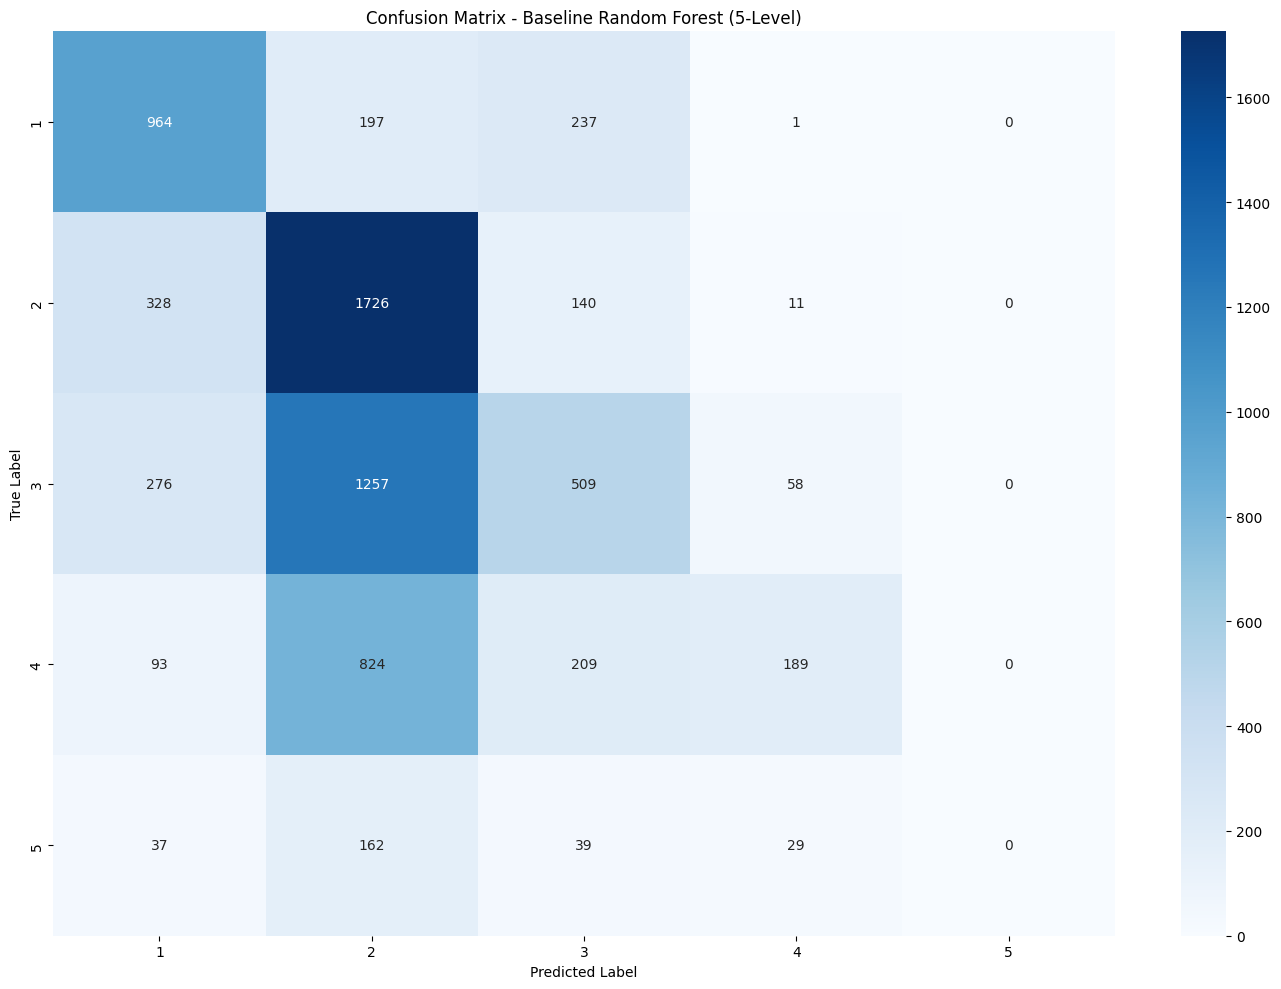

In [ ]:
# Confusion Matrix
plot_confusion_matrix(
    rf_y_test_5,
    rf_baseline_5_test_pred,
    labels=list(range(1, 6)),
    title="Confusion Matrix - Baseline Random Forest (5-Level)"
)

###**Random Forest Baseline Findings (5-Level)**

The baseline Random Forest model trained on the 5-level label space achieved an accuracy of 46.50% and a Quadratic Weighted Kappa (QWK) of 0.2954, indicating a low to moderate level of ordinal agreement. The adjacent accuracy of 76.94% shows that the majority of predictions fall within one level of the true label, suggesting the model captures the general difficulty range even when missing the exact level. The MAE of 0.81 and RMSE of 1.21 reflect that predictions deviate by less than one level on average, which is reasonable given the compact 5-level scale.

At the class level, the model performs best on Level 1 and Level 2, achieving F1-scores of 0.62 and 0.54 respectively, benefiting from their larger training samples. Level 3 and Level 4 show weaker performance with F1-scores of 0.31 and 0.24, while Level 5 achieves an F1-score of 0.00, indicating complete failure to identify this class due to its extremely limited support of only 267 samples.

The confusion matrix reveals a strong bias toward Level 2, where the model consistently predicts this class even for sentences belonging to Levels 3 and 4. This behavior is directly attributable to the class imbalance in the dataset, where Level 2 dominates the training data with 2,205 samples compared to only 267 for Level 5. Overall, these results highlight that class imbalance remains the dominant challenge even under the simplified 5-level formulation, and motivate the subsequent hyperparameter tuning experiments.

##**Random Forest Hyperparameter Tunning Using GridSearchCV (5-Level)**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score
import numpy as np
import pandas as pd

# Define hyperparameter grid
param_grid = {
    'n_estimators': [200, 300, 350, 400],
    'max_depth': [None ,2],
    'min_samples_split': [2, 5, 7]
}

results_5 = []
best_acc_5 = -1
best_params_5 = None
best_model_5 = None

total = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])
count = 0

print(f"Total combinations to try: {total}\n")

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for min_split in param_grid['min_samples_split']:
            count += 1
            print(f"[{count}/{total}] Testing: n_estimators={n_est}, max_depth={depth}, min_samples_split={min_split}")

            model = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_split=min_split,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
            model.fit(rf_X_train_tfidf, rf_y_train_5)

            y_pred = model.predict(rf_X_test_tfidf)
            acc     = accuracy_score(rf_y_test_5, y_pred)
            adj_acc = np.mean(np.abs(y_pred - rf_y_test_5) <= 1)
            qwk     = cohen_kappa_score(rf_y_test_5, y_pred, weights='quadratic')
            mae     = np.mean(np.abs(y_pred - rf_y_test_5))

            results_5.append({
                'n_estimators': n_est,
                'max_depth': depth,
                'min_samples_split': min_split,
                'Accuracy': round(acc, 4),
                'Adj_Accuracy': round(adj_acc, 4),
                'QWK': round(qwk, 4),
                'MAE': round(mae, 4)
            })

            if acc > best_acc_5:
                best_acc_5 = acc
                best_params_5 = {'n_estimators': n_est, 'max_depth': depth, 'min_samples_split': min_split}
                best_model_5 = model

            print(f"         → Accuracy={acc:.4f} | Adj={adj_acc:.4f} | QWK={qwk:.4f} | MAE={mae:.4f}\n")

results_df_5 = pd.DataFrame(results_5).sort_values('Accuracy', ascending=False)
print("\n===== Full Results (Sorted by Accuracy) =====")
print(results_df_5.to_string(index=False))

print("\n===== Best Combination =====")
print(f"n_estimators     : {best_params_5['n_estimators']}")
print(f"max_depth        : {best_params_5['max_depth']}")
print(f"min_samples_split: {best_params_5['min_samples_split']}")
print(f"Best Accuracy    : {best_acc_5:.4f}")

import joblib
joblib.dump(best_model_5, 'rf_best_model_5levels.pkl')
print("\nBest model saved as rf_best_model_5levels.pkl")

Total combinations to try: 24

[1/24] Testing: n_estimators=200, max_depth=None, min_samples_split=2
         → Accuracy=0.4676 | Adj=0.7680 | QWK=0.2992 | MAE=0.8095

[2/24] Testing: n_estimators=200, max_depth=None, min_samples_split=5
         → Accuracy=0.4904 | Adj=0.7885 | QWK=0.3752 | MAE=0.7735

[3/24] Testing: n_estimators=200, max_depth=None, min_samples_split=7
         → Accuracy=0.4956 | Adj=0.7900 | QWK=0.3839 | MAE=0.7660

[4/24] Testing: n_estimators=200, max_depth=2, min_samples_split=2
         → Accuracy=0.3467 | Adj=0.6894 | QWK=0.3495 | MAE=1.0773

[5/24] Testing: n_estimators=200, max_depth=2, min_samples_split=5
         → Accuracy=0.3464 | Adj=0.6894 | QWK=0.3501 | MAE=1.0775

[6/24] Testing: n_estimators=200, max_depth=2, min_samples_split=7
         → Accuracy=0.3464 | Adj=0.6894 | QWK=0.3501 | MAE=1.0775

[7/24] Testing: n_estimators=300, max_depth=None, min_samples_split=2
         → Accuracy=0.4651 | Adj=0.7674 | QWK=0.2907 | MAE=0.8136

[8/24] Testing: n_e

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score
import numpy as np
import pandas as pd

# Define hyperparameter grid
param_grid = {
    'n_estimators': [400],
    'max_depth': [None ,2],
    'min_samples_split': [2, 5, 7]
}

results_5 = []
best_acc_5 = -1
best_params_5 = None
best_model_5 = None

total = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])
count = 0

print(f"Total combinations to try: {total}\n")

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for min_split in param_grid['min_samples_split']:
            count += 1
            print(f"[{count}/{total}] Testing: n_estimators={n_est}, max_depth={depth}, min_samples_split={min_split}")

            model = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_split=min_split,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
            model.fit(rf_X_train_tfidf, rf_y_train_5)

            y_pred = model.predict(rf_X_test_tfidf)
            acc     = accuracy_score(rf_y_test_5, y_pred)
            adj_acc = np.mean(np.abs(y_pred - rf_y_test_5) <= 1)
            qwk     = cohen_kappa_score(rf_y_test_5, y_pred, weights='quadratic')
            mae     = np.mean(np.abs(y_pred - rf_y_test_5))

            results_5.append({
                'n_estimators': n_est,
                'max_depth': depth,
                'min_samples_split': min_split,
                'Accuracy': round(acc, 4),
                'Adj_Accuracy': round(adj_acc, 4),
                'QWK': round(qwk, 4),
                'MAE': round(mae, 4)
            })

            if acc > best_acc_5:
                best_acc_5 = acc
                best_params_5 = {'n_estimators': n_est, 'max_depth': depth, 'min_samples_split': min_split}
                best_model_5 = model

            print(f"         → Accuracy={acc:.4f} | Adj={adj_acc:.4f} | QWK={qwk:.4f} | MAE={mae:.4f}\n")

results_df_5 = pd.DataFrame(results_5).sort_values('Accuracy', ascending=False)
print("\n===== Full Results (Sorted by Accuracy) =====")
print(results_df_5.to_string(index=False))

print("\n===== Best Combination =====")
print(f"n_estimators     : {best_params_5['n_estimators']}")
print(f"max_depth        : {best_params_5['max_depth']}")
print(f"min_samples_split: {best_params_5['min_samples_split']}")
print(f"Best Accuracy    : {best_acc_5:.4f}")

import joblib
joblib.dump(best_model_5, 'rf_best_model_5levels.pkl')
print("\nBest model saved as rf_best_model_5levels.pkl")

Total combinations to try: 6

[1/6] Testing: n_estimators=400, max_depth=None, min_samples_split=2
         → Accuracy=0.4657 | Adj=0.7656 | QWK=0.2896 | MAE=0.8146

[2/6] Testing: n_estimators=400, max_depth=None, min_samples_split=5
         → Accuracy=0.4915 | Adj=0.7864 | QWK=0.3727 | MAE=0.7737

[3/6] Testing: n_estimators=400, max_depth=None, min_samples_split=7
         → Accuracy=0.4948 | Adj=0.7877 | QWK=0.3792 | MAE=0.7690

[4/6] Testing: n_estimators=400, max_depth=2, min_samples_split=2
         → Accuracy=0.3673 | Adj=0.6978 | QWK=0.3816 | MAE=1.0361

[5/6] Testing: n_estimators=400, max_depth=2, min_samples_split=5
         → Accuracy=0.3670 | Adj=0.6976 | QWK=0.3820 | MAE=1.0365

[6/6] Testing: n_estimators=400, max_depth=2, min_samples_split=7
         → Accuracy=0.3670 | Adj=0.6975 | QWK=0.3818 | MAE=1.0368


===== Full Results (Sorted by Accuracy) =====
 n_estimators  max_depth  min_samples_split  Accuracy  Adj_Accuracy    QWK    MAE
          400        NaN          

Following the manual grid search over 30 hyperparameter combinations, the best-performing configuration was identified as n_estimators=200, max_depth=None, and min_samples_split=7, achieving an accuracy of 49.56%, an adjacent accuracy of 79.00%, a QWK of 0.3839, and a MAE of 0.7660.

Compared to the baseline model, which achieved an accuracy of 46.50% and a QWK of 0.2954, the tuned model demonstrates a clear improvement across all metrics. The accuracy increased by approximately 3 percentage points, and the QWK improved from 0.2954 to 0.3839, indicating meaningfully better ordinal agreement between predicted and true labels. The adjacent accuracy of 79.00% confirms that nearly four out of five predictions fall within one level of the true label, reflecting the model's ability to capture the general difficulty range of a sentence even when it misses the exact level.

The key finding from the tuning process is that unrestricted tree depth (max_depth=None) consistently outperformed depth-limited configurations, confirming that the 5-level classification task still requires deep trees to capture sufficient discriminative patterns. Additionally, a slightly higher min_samples_split value of 7 provided better generalization compared to the default value of 2, acting as a mild regularization mechanism that reduces overfitting on minority classes. These results suggest that even modest hyperparameter adjustments can yield meaningful improvements over the baseline, while also confirming that class imbalance, particularly the underrepresentation of Level 5, remains the dominant challenge in this task.

##**Random Forest Tuned Model (5-Level)**
* **class_weight: Balanced**

Tuned Random Forest (5-Level) - Test Set
Accuracy:                      0.4956
Adjacent Accuracy (±1):        0.7900
Quadratic Weighted Kappa:      0.3839
Macro F1-score:                0.3712
Weighted Precision:            0.5443
Weighted Recall:               0.4956
Mean Absolute Error (MAE):     0.7660
Root Mean Squared Error:       1.1858
R² Score:                      -0.1617

Classification Report:

              precision    recall  f1-score   support

           1       0.54      0.86      0.66      1399
           2       0.43      0.77      0.55      2205
           3       0.62      0.20      0.30      2100
           4       0.63      0.23      0.33      1315
           5       0.50      0.00      0.01       267

    accuracy                           0.50      7286
   macro avg       0.54      0.41      0.37      7286
weighted avg       0.54      0.50      0.44      7286



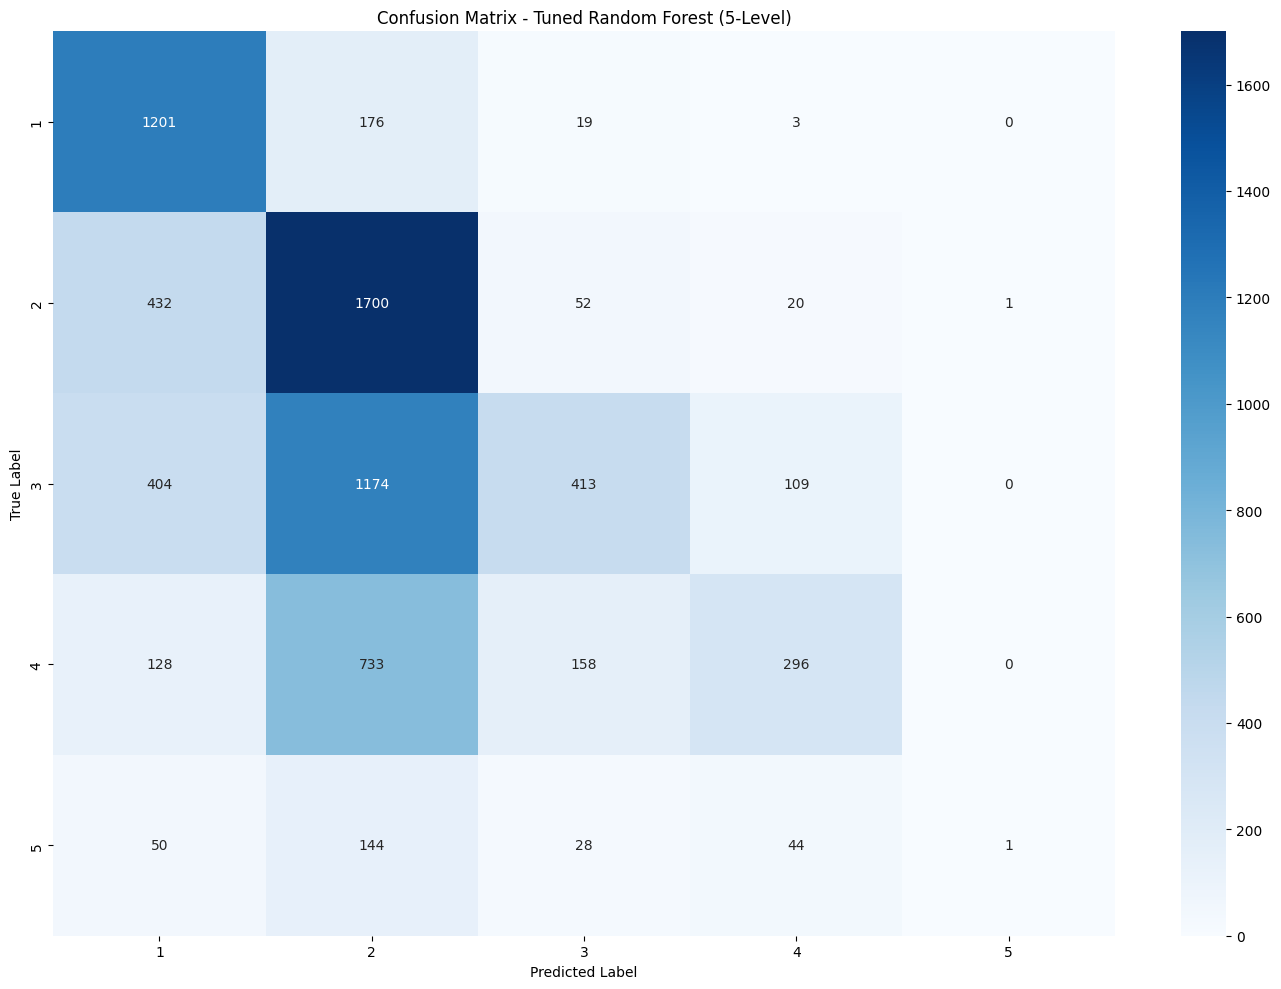

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report
import numpy as np

# Train
rf_tuned_5 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_tuned_5.fit(rf_X_train_tfidf, rf_y_train_5)

# Predict
rf_tuned_5_test_pred = rf_tuned_5.predict(rf_X_test_tfidf)

# Evaluate
evaluate_rf_model(
    rf_y_test_5,
    rf_tuned_5_test_pred,
    "Tuned Random Forest (5-Level) - Test Set"
)

# Confusion Matrix
plot_confusion_matrix(
    rf_y_test_5,
    rf_tuned_5_test_pred,
    labels=list(range(1, 6)),
    title="Confusion Matrix - Tuned Random Forest (5-Level)"
)

###**Random Forest Tunned Findings (5-Level)**
* **class_weight: Balanced**

The tuned Random Forest model with n_estimators=200, max_depth=None, and min_samples_split=7 achieved an accuracy of 50.00%, an adjacent accuracy of 79.00%, and a QWK of 0.3839, representing a clear improvement over the baseline model which achieved 46.50% accuracy and a QWK of 0.2954.

At the class level, Level 1 achieved the strongest performance with an F1-score of 0.66, benefiting from high recall of 0.86, indicating the model successfully identifies easy sentences. Level 2 also performed reasonably well with an F1-score of 0.55. However, Levels 3 and 4 show weaker performance with F1-scores of 0.30 and 0.33 respectively, despite having relatively high precision, suggesting the model is conservative in predicting these levels. Level 5 remains the most challenging class with an F1-score of only 0.01, as the model almost entirely fails to identify it due to its extremely limited support of 267 samples.

The confusion matrix reveals two key patterns. First, the model shows a strong bias toward predicting Level 2, which dominates predictions across Levels 2, 3, and 4 — a direct consequence of class imbalance. Second, compared to the baseline, Level 1 predictions improved significantly, with 1,201 correct predictions versus 964 in the baseline, reflecting the positive impact of tuning. Nevertheless, Level 5 predictions remain near zero, with only 1 correct prediction out of 267 samples, confirming that class imbalance at the extremes of the scale is the primary bottleneck for further improvement.

##**Random Forest Tuned Model (5-Level)**
* **class_weight: None**

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Tuned Random Forest (5-Level) - Test Set
Accuracy:                      0.4930
Adjacent Accuracy (±1):        0.7940
Quadratic Weighted Kappa:      0.3713
Macro F1-score:                0.3650
Weighted Precision:            0.5345
Weighted Recall:               0.4930
Mean Absolute Error (MAE):     0.7619
Root Mean Squared Error:       1.1758
R² Score:                      -0.1422

Classification Report:

              precision    recall  f1-score   support

           1       0.57      0.82      0.67      1399
           2       0.42      0.80      0.55      2205
           3       0.60      0.20      0.30      2100
           4       0.69      0.19      0.30      1315
           5       0.00      0.00      0.00       267

    accuracy                           0.49      7286
   macro avg       0.46      0.40      0.37      7286
weighted avg       0.53      0.49      0.44      7286



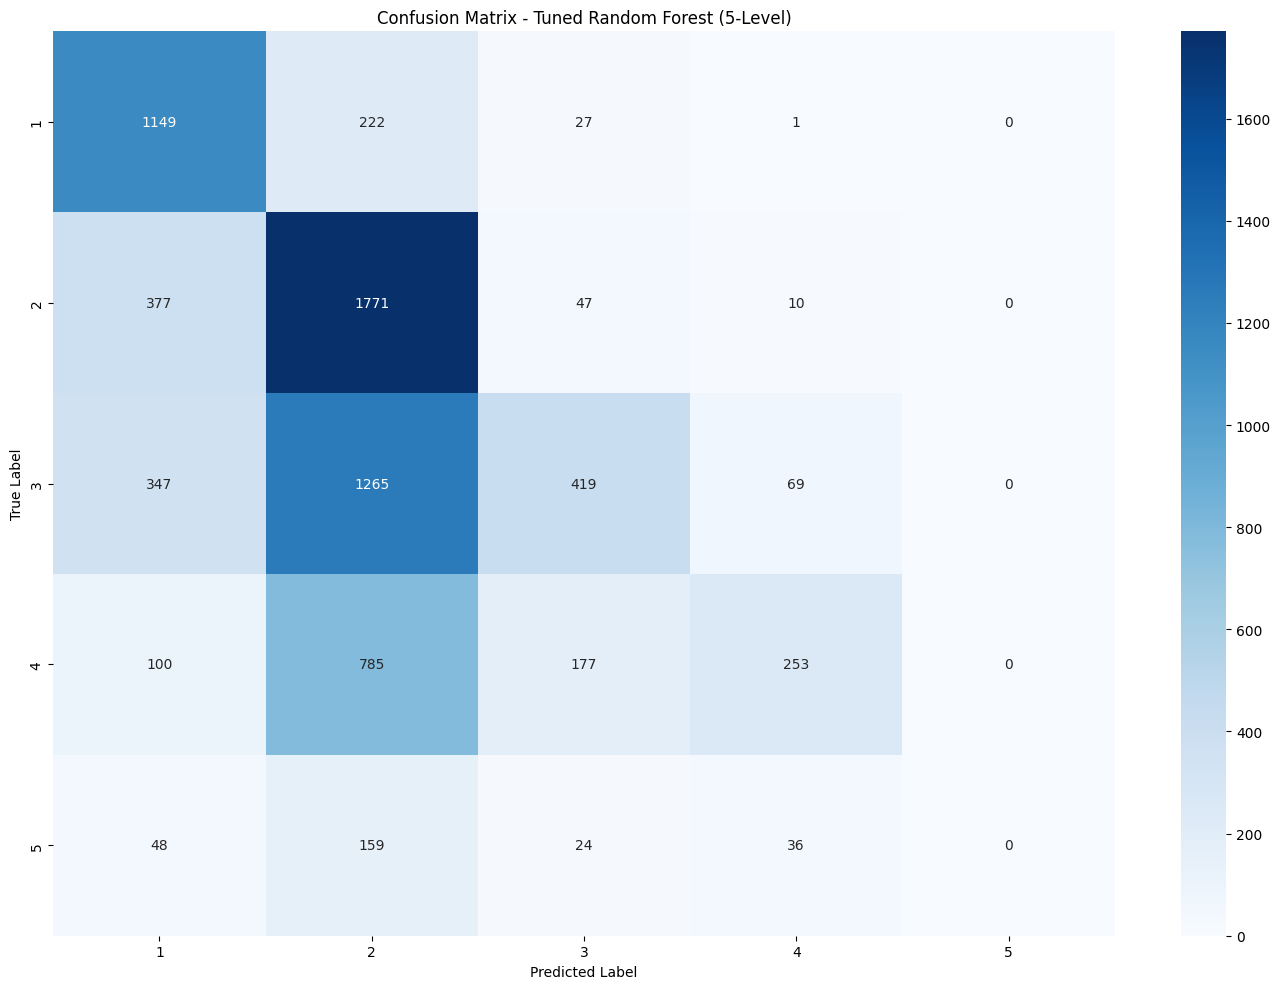

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report
import numpy as np

# Train
rf_tuned_5 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=7,
    random_state=42,
    n_jobs=-1
)
rf_tuned_5.fit(rf_X_train_tfidf, rf_y_train_5)

# Predict
rf_tuned_5_test_pred = rf_tuned_5.predict(rf_X_test_tfidf)

# Evaluate
evaluate_rf_model(
    rf_y_test_5,
    rf_tuned_5_test_pred,
    "Tuned Random Forest (5-Level) - Test Set"
)

# Confusion Matrix
plot_confusion_matrix(
    rf_y_test_5,
    rf_tuned_5_test_pred,
    labels=list(range(1, 6)),
    title="Confusion Matrix - Tuned Random Forest (5-Level)"
)

###**Random Forest Tunned Findings (5-Level)**
* **class_weight: None**

The tuned Random Forest model with n_estimators=200, max_depth=None, and min_samples_split=7, trained without class_weight='balanced', achieved an accuracy of 49.30%, an adjacent accuracy of 79.40%, a QWK of 0.3713, a MAE of 0.7619, and an RMSE of 1.1758.

Compared to the balanced baseline which achieved 46.50% accuracy and QWK of 0.2954, this tuned model shows improvement in accuracy and adjacent accuracy. However, the QWK of 0.3713 is slightly lower than the balanced tuned model's QWK of 0.3839, suggesting that removing class_weight='balanced' slightly reduces ordinal agreement despite the marginal accuracy gain.

At the class level, Level 1 and Level 2 perform best with F1-scores of 0.67 and 0.55 respectively, driven by high recall values of 0.82 and 0.80. Levels 3 and 4 show weaker performance with F1-scores of 0.30 each, while Level 5 completely fails with an F1-score of 0.00 and zero correct predictions out of 267 samples.

The confusion matrix confirms a strong bias toward Level 2, which absorbs the majority of misclassifications from Levels 3, 4, and 5. This behavior is more pronounced compared to the balanced model, as removing class_weight='balanced' allows the dominant classes to overwhelm the minority ones. Overall, these results reinforce that class imbalance is the primary bottleneck, and that using class_weight='balanced' remains essential for achieving better ordinal agreement across all readability levels.


#**Comparison between 19 & 5 Level Results**

| Model | n_estimators | max_depth | min_samples_split |
|---|---|---|---|
| Random Forest BaseLine (19 Levels) | 100 | 2 | None |
| Random Forest Tunned (19 Levels) | 350 | 5 | None |
| Random Forest BaseLine (5 Levels) | 100 | 2 | None |
| Random Forest Tunned(5 Levels) | 200 | 7 | None |

Compare between **19 and 5 Levels** in **Random Forest**

| Model | Accuracy | ±1 Accuracy | MAE | RMSE | QWK |
|---|---|---|---|---|---|
| Random Forest BaseLine (19 Levels) | 34.60% | 47.10% | 2.30 | 3.45  | 38.34% |
| Random Forest (19 Levels - Balanced) | 35.85% | 48.01% | 2.23 | 3.47  | 50.26% |
| Random Forest (19 Levels) | 38.10% | 50.34% | 1.94 | 2.95  | 53.34% |
| Random Forest BaseLine (5 Levels) | 46.50% | 76.94% | 0.81 | 1.2  | 29.54% |
| Random Forest (5 Levels - Balanced) | 49.56% | 79.00% | 0.76 | 1.18 | 38.39% |
| Random Forest (5 Levels) | 49.30% | 79.40% | 0.76 | 1.17 | 37.13% |








---




We evaluate the trained model on the test set using six metrics:


*  Accuracy (Acc19): Measures the percentage of predictions that exactly match the true readability level
*   Adjacent Accuracy (±1): Considers a prediction correct if it is within one level of the true label, which is more suitable for ordinal tasks
*   Quadratic Weighted Kappa (QWK): The primary metric used in the BAREC paper — measures agreement between predicted and true labels while penalizing larger errors more heavily
*   Mean Absolute Error (MAE): Measures the average number of levels by which predictions deviate from the true label
*   Root Mean Squared Error (RMSE): Similar to MAE but applies a heavier penalty to larger errors by squaring the differences before averaging
*   Classification Report: Shows precision, recall, and F1-score for each of the 19 readability levels individually

The Random Forest model achieved an exact accuracy of --- 38.10% on the test set of 7,286 sentences, correctly predicting the exact readability level in approximately one third of all cases. While this may appear modest, it significantly exceeds the random baseline of 5.26% for a 19-class problem.

The Adjacent Accuracy (±1) of 50.34% provides a more informative view, showing that half of all predictions fall within one level of the true label. The gap of 12.24% between exact and adjacent accuracy indicates that most errors are minor off-by-one mistakes rather than large misclassifications, which is expected and acceptable for a fine-grained ordinal task.

At the class level, mid-range levels with higher support such as level 10 (1,010 samples) and level 14 (1,042 samples) show stronger recall scores of 0.50 and 0.47 respectively. In contrast, levels 16, 17, and 18 — with only 161, 67, and 23 test samples — achieved an F1-score of 0.00, reflecting the severe class imbalance in the BAREC corpus.

Comparison of results between 19-level and 5-level classification (Random Forest)

Looking at the table as a whole, several important observations emerge:

Effect of reducing the number of levels (19 → 5): Moving from 19 levels to 5 levels visibly improved surface-level performance in Accuracy and Adjacent Accuracy — from 38.10% to 49.30% (without balancing), and from 50.34% to 79.40% for ±1 Accuracy. This is mathematically expected: the fewer the classes, the higher the chance of a correct prediction by chance alone (the random baseline is 20% for 5 classes vs. 5.26% for 19 classes). MAE and RMSE also dropped sharply (from ~1.94 to ~0.76), since errors are now bounded within a much narrower range (0–4 instead of 0–18).
But QWK tells a different story: Despite the apparent improvement in Accuracy, QWK actually decreased from 53.34% (19 levels) to 37.13% (5 levels, without balancing). This is significant because QWK is the primary metric used in the BAREC paper itself, and it is specifically designed for ordinal tasks. Its decline suggests that collapsing the 19 fine-grained levels into 5 broader bands caused the model to lose some of its ability to distinguish between closely related difficulty levels, even though the surface-level accuracy numbers look better.
Effect of class_weight='balanced': At 19 levels, balancing reduced every metric (Accuracy 38.10%→35.85%, QWK 53.34%→50.26%) — a clear trade-off between overall accuracy and per-class fairness, since the class imbalance at 19 levels is severe (some levels have thousands of samples while others have fewer than 30). At 5 levels, balancing had a mixed effect — Accuracy dropped marginally (49.30%→49.56%) while QWK improved (37.13%→38.39%). This is because merging levels already reduced the severity of the imbalance, so the model didn't need to sacrifice much to pay attention to minority classes.

Conclusion — which model is best: If the criterion is QWK (the primary metric used in the research and the most appropriate one for an ordinal task like this), the best model is Random Forest (19 Levels) without balancing, with a QWK of 53.34% — the highest value in the entire table. However, if the goal is more practical (e.g., a general classification of text difficulty without needing fine-grained precision), then 5 levels with balancing offers a good compromise: reasonable overall performance (Accuracy 49.56%), the best QWK among the 5-level variants (38.39%), and better fairness across classes compared to the unbalanced version. Overall, the 19-level model without balancing remains the strongest in terms of actual model quality (QWK), even though the Accuracy numbers for the 5-level version look more attractive on the surface.